In [6]:
# preprocessing imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# classification imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# unsupervised import
from sklearn.cluster import KMeans

# metrics imports
from sklearn.metrics import confusion_matrix, classification_report

# geopy imports (for distance function)
%pip install geopy
from geopy import distance
# install imblearn 
%pip install imblearn
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
# def final feature set (add to this list for each function)
FEATURES = ['day_of_week', 'hour_of_day', 'is_weekend', 'is_nighttime',
            'amt_to_median_ratio', 'amt_zscore',
            'new_merchant_flag', "merchant_fraud_rate", 'category_frequency',
            'transDistance', 'merchant_travel_distance_24hr', 'impossible_travel_flag',
            'transaction_count_1h', 'transaction_count_24h', 'total_amount_1h', 'total_amount_24h', 'time_since_last_transaction'
            ]



In [100]:
# Date Related Features [day_of_week, hour_of_day, is_weekend, is_nighttime]
def dateFeatures(df):
  # getting day of week (integer from 1-7)
  df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
  # getting hour of the day
  df['hour_of_day'] = df['trans_date_trans_time'].dt.hour
  # getting boolean value for weekend/non-weekend transaction
  # 1=weekend, 0=not-weekend
  df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
  # getting boolean value if night transaction (from 10 PM to 6 AM)
  df['is_nighttime'] = ((df['hour_of_day'] < 6) | (df['hour_of_day'] > 21)).astype(int)
  return df

In [101]:
# Amount related features [amt_to_median_ratio, amt_zcore]
def amountFeatures(df):
  # Group by credit card and look at the 'amt' column
  card_amt = df.groupby("cc_num")["amt"]

  # Median amount per card
  median_amt = card_amt.transform("median")
  df["amt_to_median_ratio"] = df["amt"] / median_amt

  # Mean and std per card for z-score
  mean_amt = card_amt.transform("mean")
  std_amt = card_amt.transform("std")

  # Avoid division by zero: if std = 0 or NaN, set z-score to 0
  std_safe = std_amt.replace(0, np.nan)
  df["amt_zscore"] = (df["amt"] - mean_amt) / std_safe
  df["amt_zscore"] = df["amt_zscore"].fillna(0)

  return df

In [102]:
# Merchant and category features

def newMerchantFlag(df):
  # check if merchant is a new merchant
  df = df.copy()
  df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

  # Keep original order but sort by order of transaction time, indicate if it is a first time merchant
  df["_orig_idx"] = range(len(df))
  df = df.sort_values(["cc_num", "trans_date_trans_time"])
  df["new_merchant_flag"] = (
        df.groupby(["cc_num", "merchant"]).cumcount() == 0
    ).astype(int)

  # Restore original order
  df = df.sort_values("_orig_idx").drop(columns=["_orig_idx"])

  return df

def merchantFraudRate(df):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

    # sorting by date
    df["_orig_idx"] = range(len(df))
    df = df.sort_values(["merchant", "trans_date_trans_time"])

    prev_count = df.groupby("merchant").cumcount()
    fraud_count = df.groupby("merchant")["is_fraud"].cumsum() - df["is_fraud"]
    df["merchant_fraud_rate"] = 0.0
    mask = prev_count > 0
    df.loc[mask, "merchant_fraud_rate"] = fraud_count[mask] / prev_count[mask]
    df = df.sort_values("_orig_idx").drop(columns=["_orig_idx"])

    return df

def categoryFrequency(df, start_from_one=True):

    #Calculates how often each cardholder (cc_num) uses each merchant category.
    df = df.copy()
    df["_orig_idx"] = range(len(df))
    df = df.sort_values(["cc_num", "trans_date_trans_time"])

    # cumulative count
    df["category_frequency"] = df.groupby(["cc_num", "category"]).cumcount()

    # Start counting from 1
    if start_from_one:
        df["category_frequency"] += 1

    # Restore original order
    df = df.sort_values("_orig_idx").drop(columns=["_orig_idx"])
    return df

def merchantFeatures(df):
  return merchantFraudRate(newMerchantFlag(categoryFrequency(df)))



In [103]:
from geopy import distance
import pandas as pd
import numpy as np


def findDistance(df):
    df = df.copy()
    def safe_distance(row):
        lat1, lon1 = row.get('lat'), row.get('long')
        lat2, lon2 = row.get('merch_lat'), row.get('merch_long')
        if any(pd.isna(x) for x in [lat1, lon1, lat2, lon2]):
            return 0.0
        try:
            return distance.distance((lat1, lon1), (lat2, lon2)).km
        except Exception:
            return 0.0
    df["transDistance"] = df.apply(safe_distance, axis=1)
    return df


def merchantTravelDistance(df, hours=24):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["_orig_idx"] = np.arange(len(df))
    df = df.sort_values(["cc_num", "trans_date_trans_time"])

    distances = []
    time_window_sec = hours * 3600

    for _, group in df.groupby("cc_num", sort=False):
        prev_txn = None
        for _, row in group.iterrows():
            if pd.isna(row["merch_lat"]) or pd.isna(row["merch_long"]):
                distances.append(0)
                prev_txn = None
                continue

            if prev_txn:
                prev_time, prev_lat, prev_lon = prev_txn
                time_diff = (row["trans_date_trans_time"] - prev_time).total_seconds()
                if time_diff <= time_window_sec:
                    try:
                        d_km = distance.distance(
                            (row["merch_lat"], row["merch_long"]),
                            (prev_lat, prev_lon)
                        ).km
                    except Exception:
                        d_km = 0
                    distances.append(d_km)
                else:
                    distances.append(0)
            else:
                distances.append(0)

            prev_txn = (row["trans_date_trans_time"], row["merch_lat"], row["merch_long"])

    if len(distances) != len(df):
        raise ValueError(f"Distance list length {len(distances)} != df length {len(df)}")

    df[f"merchant_travel_distance_{hours}hr"] = distances
    df = df.sort_values("_orig_idx").drop(columns=["_orig_idx"])
    return df


def flagImpossibleTravel(df, speed_threshold_kmh=300):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["_orig_idx"] = np.arange(len(df))
    df = df.sort_values(["cc_num", "trans_date_trans_time"])

    dist_list, time_diff_list, speed_list, flag_list = [], [], [], []

    for _, group in df.groupby("cc_num", sort=False):
        prev_txn = None
        for _, row in group.iterrows():
            if prev_txn:
                prev_time, prev_lat, prev_lon = prev_txn
                time_diff = (row["trans_date_trans_time"] - prev_time).total_seconds() / 3600
                try:
                    dist_km = distance.distance(
                        (row["merch_lat"], row["merch_long"]),
                        (prev_lat, prev_lon)
                    ).km
                except Exception:
                    dist_km = 0
                speed = dist_km / time_diff if time_diff > 0 else 0
                flag = int(speed > speed_threshold_kmh)
            else:
                dist_km, time_diff, speed, flag = 0, 0, 0, 0

            dist_list.append(dist_km)
            time_diff_list.append(time_diff)
            speed_list.append(speed)
            flag_list.append(flag)
            prev_txn = (row["trans_date_trans_time"], row["merch_lat"], row["merch_long"])

    # sanity check
    if len(dist_list) != len(df):
        raise ValueError(f"Speed list length {len(dist_list)} != df length {len(df)}")

    df["dist_prev_km"] = dist_list
    df["time_diff_hr"] = time_diff_list
    df["travel_speed_kmh"] = speed_list
    df["impossible_travel_flag"] = flag_list

    df = df.sort_values("_orig_idx").drop(columns=["_orig_idx"])
    return df


def distanceFeatures(df):
    df = findDistance(df)
    df = merchantTravelDistance(df)
    df = flagImpossibleTravel(df)
    return df


In [104]:
def add_transaction_count_1h(df, card_col='cc_num', ts_col='trans_date_trans_time'):
    d = df.copy()
    d['_orig_idx'] = np.arange(len(d))
    d = d.sort_values([card_col, ts_col])
    d['_ones'] = 1

    def _roll(g):
        return g.rolling('1h', on=ts_col)['_ones'].sum().sub(1).fillna(0).astype(int)

    d['transaction_count_1h'] = d.groupby(card_col, group_keys=False).apply(_roll)
    d = d.drop(columns=['_ones'])
    d = d.sort_values('_orig_idx').drop(columns=['_orig_idx'])
    return d


def add_transaction_count_24h(df, card_col='cc_num', ts_col='trans_date_trans_time'):
    d = df.copy()
    d['_orig_idx'] = np.arange(len(d))
    d = d.sort_values([card_col, ts_col])
    d['_ones'] = 1

    def _roll(g):
        return g.rolling('24h', on=ts_col)['_ones'].sum().sub(1).fillna(0).astype(int)

    d['transaction_count_24h'] = d.groupby(card_col, group_keys=False).apply(_roll)
    d = d.drop(columns=['_ones'])
    d = d.sort_values('_orig_idx').drop(columns=['_orig_idx'])
    return d

def add_total_amount_1h(df, card_col='cc_num', ts_col='trans_date_trans_time', amt_col='amt'):
    d = df.copy()
    d['_orig_idx'] = np.arange(len(d))
    d = d.sort_values([card_col, ts_col])

    def _roll(g):
        s = g.rolling('1h', on=ts_col)[amt_col].sum()
        return (s - g[amt_col]).fillna(0.0)

    d['total_amount_1h'] = d.groupby(card_col, group_keys=False).apply(_roll)
    d = d.sort_values('_orig_idx').drop(columns=['_orig_idx'])
    return d

def add_total_amount_24h(df, card_col='cc_num', ts_col='trans_date_trans_time', amt_col='amt'):
    d = df.copy()
    d['_orig_idx'] = np.arange(len(d))
    d = d.sort_values([card_col, ts_col])

    def _roll(g):
        s = g.rolling('24h', on=ts_col)[amt_col].sum()
        return (s - g[amt_col]).fillna(0.0)

    d['total_amount_24h'] = d.groupby(card_col, group_keys=False).apply(_roll)
    d = d.sort_values('_orig_idx').drop(columns=['_orig_idx'])
    return d

def add_time_since_last_transaction(df, card_col='cc_num', ts_col='trans_date_trans_time'):
    d = df.copy()
    if not np.issubdtype(d[ts_col].dtype, np.datetime64):
        d[ts_col] = pd.to_datetime(d[ts_col], errors='coerce')

    sidx = d[[card_col, ts_col]].sort_values([card_col, ts_col]).index
    prev = d.loc[sidx].groupby(d.loc[sidx, card_col])[ts_col].shift(1)
    delta = (d.loc[sidx, ts_col] - prev).dt.total_seconds().fillna(0.0)
    d['time_since_last_transaction'] = pd.Series(delta.values, index=sidx).reindex(df.index).values
    return d


def velocityFeatures(df):
    print(".   Finding Transaction Counts")
    df = add_transaction_count_1h(df)
    df = add_transaction_count_24h(df)
    print(".   Finding Total Spent")
    df = add_total_amount_1h(df)
    df = add_total_amount_24h(df)
    df = add_time_since_last_transaction(df)
    return df

In [24]:
def preprocessData(useExisting=True):

  testX, testY, trainX, trainY = None, None, None, None
  try:
    if not useExisting:
      raise Exception("Forcing re-preprocessing of data")
    testX = pd.read_csv('testX.csv')
    testY = pd.read_csv('testY.csv')
    trainX = pd.read_csv('trainX.csv')
    trainY = pd.read_csv('trainY.csv')
  except:
    print("Preprocessing Data from Scratch")
    trainDf = pd.read_csv('fraudTrain.csv', parse_dates=['trans_date_trans_time'])
    testDf = pd.read_csv('fraudTest.csv', parse_dates=['trans_date_trans_time'])

    # preprocess train set
    print("Preprocessing Train Set")
    print("=" * 50)
    print("  Creating Date Features")
    trainDf = dateFeatures(trainDf)
    print("  Creating Amount Features")
    trainDf = amountFeatures(trainDf)
    print("  Creating Merchant Features")
    trainDf = merchantFeatures(trainDf)
    print("  Creating Distance Features")
    trainDf = distanceFeatures(trainDf)
    print("  Creating Velocity Features")
    trainDf = velocityFeatures(trainDf)
    trainX = trainDf.drop(columns=['is_fraud'])
    trainY = trainDf['is_fraud']

    # preprocess test
    print("Preprocessing Test Set")
    print("=" * 50)
    print("  Creating Date Features")
    testDf = dateFeatures(testDf)
    print("  Creating Amount Features")
    testDf = amountFeatures(testDf)
    print("  Creating Merchant Features")
    testDf = merchantFeatures(testDf)
    print("  Creating Distance Features")
    testDf = distanceFeatures(testDf)
    print("  Creating Velocity Features")
    testDf = velocityFeatures(testDf)
    testX = testDf.drop(columns=['is_fraud'])
    testY = testDf['is_fraud']

    # save to csv for future
    trainX.to_csv('trainX.csv', index=False)
    trainY.to_csv('trainY.csv', index=False)
    testX.to_csv('testX.csv', index=False)
    testY.to_csv('testY.csv', index=False)

  return (trainX, trainY, testX, testY)

trainX, trainY, testX, testY = preprocessData()
trainX = trainX[FEATURES]
testX = testX[FEATURES]
trainY = trainY['is_fraud']
testY = testY['is_fraud']

# Apply Smote to fix datset imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
trainX, trainY = smote.fit_resample(trainX, trainY)


In [116]:
print('random forest')
print('=' * 50)
clf_RF = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
clf_RF.fit(trainX, trainY)
y_pred_rf = clf_RF.predict(testX)
print(classification_report(testY, y_pred_rf))

random forest
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.22      0.85      0.35      2145

    accuracy                           0.99    555719
   macro avg       0.61      0.92      0.67    555719
weighted avg       1.00      0.99      0.99    555719



In [117]:
print('stochastic gradient descent')
print('=' * 50)
clf_SGD = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, random_state=42, max_iter=1000, tol=1e-3)
clf_SGD.fit(trainX, trainY)
y_pred_SGD = clf_SGD.predict(testX)
print(classification_report(testY, y_pred_SGD))

stochastic gradient descent
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    553574
           1       0.05      0.86      0.10      2145

    accuracy                           0.94    555719
   macro avg       0.53      0.90      0.53    555719
weighted avg       1.00      0.94      0.97    555719



In [118]:
print("Multi-layer Perceptron")
print('=' * 50)
clf_MLP = MLPClassifier(hidden_layer_sizes=(100,), max_iter=100, random_state=42)
clf_MLP.fit(trainX, trainY)
y_pred_MLP = clf_MLP.predict(testX)
print(classification_report(testY, y_pred_MLP))

Multi-layer Perceptron
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.09      0.89      0.17      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.93      0.58    555719
weighted avg       1.00      0.97      0.98    555719



In [119]:
# train XGBoost model Best Parameter Combination: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 8, 'classifier__subsample': 0.8} objective='binary:logistic', eval_metric='aucpr', tree_method='hist'
print("XGBoost Classifier")
print('=' * 50)
clf_XGB = xgb.XGBClassifier(objective='binary:logistic', eval_metric='aucpr', tree_method='hist', colsample_bytree=0.7, learning_rate=0.05, max_depth=8, subsample=0.8)
clf_XGB.fit(trainX, trainY)
y_pred_XGB = clf_XGB.predict(testX)
print(classification_report(testY, y_pred_XGB))

XGBoost Classifier
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.13      0.91      0.23      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.94      0.61    555719
weighted avg       1.00      0.98      0.99    555719



In [120]:
# ensemble classifier with soft voting consisting of random forest, sgd, mlp, xgboost
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(estimators=[
    ('rf', clf_RF),
    ('sgd', clf_SGD),
    ('mlp', clf_MLP),
    ('xgb', clf_XGB)
], voting='soft', n_jobs=-1)
voting_clf.fit(trainX, trainY)
y_pred_ensemble = voting_clf.predict(testX)
print(classification_report(testY, y_pred_ensemble))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.13      0.89      0.23      2145

    accuracy                           0.98    555719
   macro avg       0.56      0.94      0.61    555719
weighted avg       1.00      0.98      0.99    555719



In [121]:
# XGBoost
# preprocessing
numeric = ['is_weekend', 'is_nighttime', 'amt_to_median_ratio', 'amt_zscore', 'new_merchant_flag', 'category_frequency',
           'transDistance', 'merchant_travel_distance_24hr', 'impossible_travel_flag', 'transaction_count_1h',
           'transaction_count_24h', 'total_amount_1h', 'total_amount_24h', 'time_since_last_transaction']
categorical = ['day_of_week', 'hour_of_day']
preprocessor = ColumnTransformer(transformers=[
 ('num', StandardScaler(), numeric),
 ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])

# creating pipeline
pipe = Pipeline([
 ('pre', preprocessor),
 ('classifier', xgb.XGBClassifier(objective='binary:logistic', eval_metric='aucpr', tree_method='hist', random_state=42, n_jobs=-1))
])

# parameter optimization
param_grid = {
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [7, 8],
    'classifier__subsample': [0.7, 0.8],
    'classifier__colsample_bytree': [0.7, 0.8]
}

# find best combination of parameters
grid_search = GridSearchCV(pipe, param_grid, cv=3, scoring='average_precision', n_jobs=1, verbose=3)
grid_search.fit(trainX, trainY)
print(f"Best Parameter Combination: {grid_search.best_params_}")
best_xgboost = grid_search.best_estimator_

# fraud prediction on test set
pred_fraud = best_xgboost.predict_proba(testX)[:,1]
pred_fraud = (pred_fraud > 0.5).astype(int)

# model evaluation
print("PR AUC:", average_precision_score(testY, pred_fraud))
print("Classification Report:\n", classification_report(testY, pred_fraud))
print("Confusion Matrix:\n", confusion_matrix(testY, pred_fraud))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV 1/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsample=0.7;, score=0.988 total time=   6.5s
[CV 2/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsample=0.7;, score=0.996 total time=   6.1s
[CV 3/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsample=0.7;, score=0.996 total time=   6.0s
[CV 1/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsample=0.8;, score=0.987 total time=   6.0s
[CV 2/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsample=0.8;, score=0.996 total time=   5.8s
[CV 3/3] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__subsampl

In [26]:
import itertools
def visualizeMetrics(cm, classes, title='Confusion matrix',
                     cmap=plt.cm.Blues, normalize=True):
    cm = np.asarray(cm)
    cm_for_colors = cm.astype(float)

    if normalize:
        #  recall based normalizationfor coloring only for imbalanced datsets
        row_sums = cm_for_colors.sum(axis=1, keepdims=True)
        cm_for_colors = cm_for_colors / row_sums

    plt.figure()
    im = plt.imshow(cm_for_colors, interpolation='nearest', cmap=cmap,
                    vmin=0, vmax=1 if normalize else None)
    plt.title(title)
    plt.colorbar(im)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm_for_colors.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        text_str = f"{cm[i, j]:,}"   
        plt.text(j, i, text_str,
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm_for_colors[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"True Negative: {tn}")
    print(f"False Positive: {fp}")
    print(f"False Negative: {fn}")
    print(f"True Positive: {tp}")

    tnr = round((tn / (tn + fp)) * 100, 3)
    tpr = round((tp / (tp + fn)) * 100, 3)
    fpr = round((fp / (fp + tn)) * 100, 3)
    fnr = round((fn / (fn + tp)) * 100, 3)

    print(f"True Negative Rate: {tnr}%")
    print(f"True Positive Rate: {tpr}%")
    print(f"False Positive Rate: {fpr}%")
    print(f"False Negative Rate: {fnr}%")

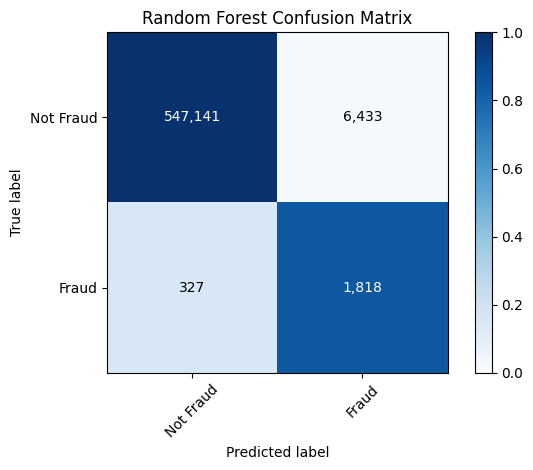

True Negative: 547141
False Positive: 6433
False Negative: 327
True Positive: 1818
True Negative Rate: 98.838%
True Positive Rate: 84.755%
False Positive Rate: 1.162%
False Negative Rate: 15.245%


In [123]:
# visualize confusion matrix for random forest
cm_rf = confusion_matrix(testY, y_pred_rf)
visualizeMetrics(cm_rf, classes=['Not Fraud', 'Fraud'], title='Random Forest Confusion Matrix')

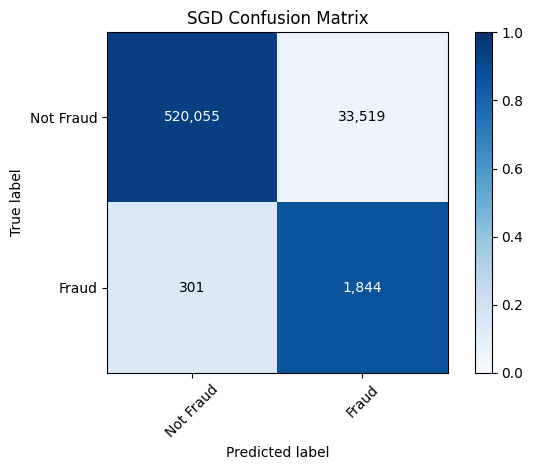

True Negative: 520055
False Positive: 33519
False Negative: 301
True Positive: 1844
True Negative Rate: 93.945%
True Positive Rate: 85.967%
False Positive Rate: 6.055%
False Negative Rate: 14.033%


In [124]:
# visualize confusion matrix for sgd
cm_sgd = confusion_matrix(testY, y_pred_SGD)
visualizeMetrics(cm_sgd, classes=['Not Fraud', 'Fraud'], title='SGD Confusion Matrix')


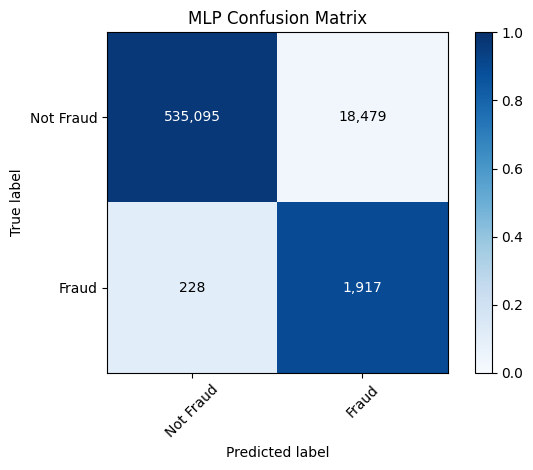

True Negative: 535095
False Positive: 18479
False Negative: 228
True Positive: 1917
True Negative Rate: 96.662%
True Positive Rate: 89.371%
False Positive Rate: 3.338%
False Negative Rate: 10.629%


In [125]:
# visualize confusion matrix for mlp
cm_mlp = confusion_matrix(testY, y_pred_MLP)
visualizeMetrics(cm_mlp, classes=['Not Fraud', 'Fraud'], title='MLP Confusion Matrix')


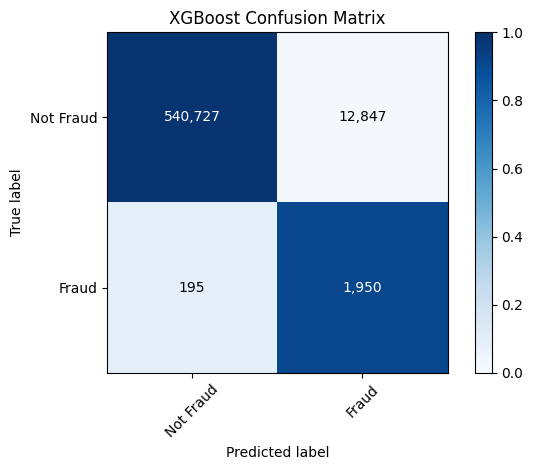

True Negative: 540727
False Positive: 12847
False Negative: 195
True Positive: 1950
True Negative Rate: 97.679%
True Positive Rate: 90.909%
False Positive Rate: 2.321%
False Negative Rate: 9.091%


In [126]:
# visualize confusion matrix for XGBoost
cm_xgb = confusion_matrix(testY, y_pred_XGB)
visualizeMetrics(cm_xgb, classes=['Not Fraud', 'Fraud'], title='XGBoost Confusion Matrix')

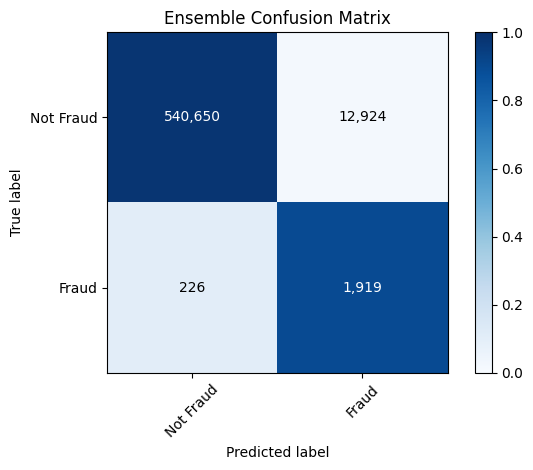

True Negative: 540650
False Positive: 12924
False Negative: 226
True Positive: 1919
True Negative Rate: 97.665%
True Positive Rate: 89.464%
False Positive Rate: 2.335%
False Negative Rate: 10.536%


In [127]:
# visualize confusion matrix for ensemble
cm_ensemble = confusion_matrix(testY, y_pred_ensemble)
visualizeMetrics(cm_ensemble, classes=['Not Fraud', 'Fraud'], title='Ensemble Confusion Matrix')

Feature Importances from XGBoost:
                          Feature  Importance
5                      amt_zscore    0.294690
14               total_amount_24h    0.236537
4             amt_to_median_ratio    0.130703
3                    is_nighttime    0.085182
1                     hour_of_day    0.048502
12          transaction_count_24h    0.041967
13                total_amount_1h    0.038712
2                      is_weekend    0.033347
15    time_since_last_transaction    0.021034
0                     day_of_week    0.019294
7              category_frequency    0.014802
6               new_merchant_flag    0.014227
11           transaction_count_1h    0.007256
10         impossible_travel_flag    0.006291
9   merchant_travel_distance_24hr    0.003816
8                   transDistance    0.003640


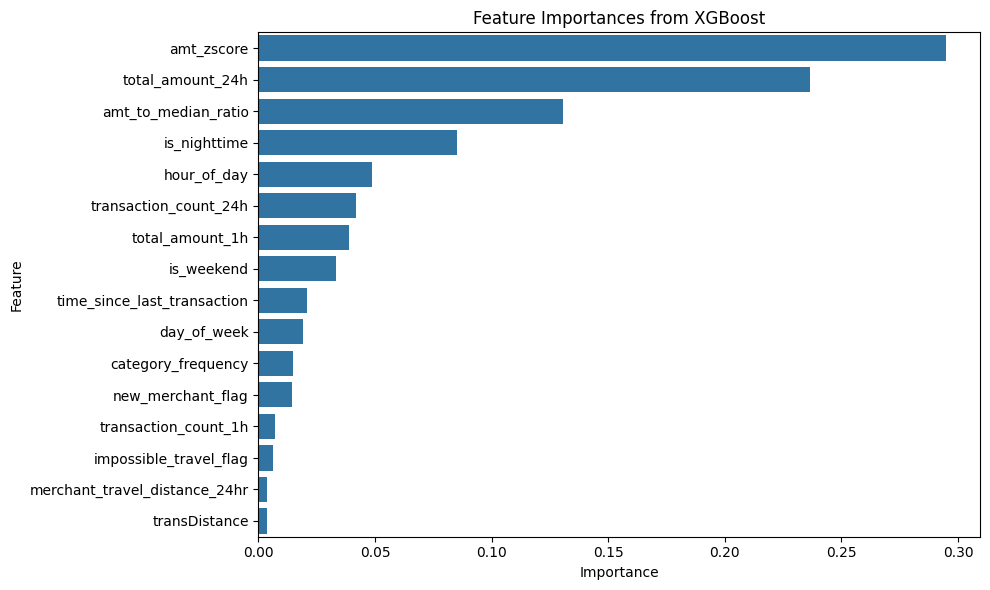

In [128]:
# feature importance from XGBOOST
importances = clf_XGB.feature_importances_
feature_names = trainX.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature Importances from XGBoost:")
print(feature_importance_df)

# make a nice ploy too
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

KMeans Clustering
Fitting KMeans with k=1
Fitting KMeans with k=2
Fitting KMeans with k=3
Fitting KMeans with k=4
Fitting KMeans with k=5
Fitting KMeans with k=6
Fitting KMeans with k=7
Fitting KMeans with k=8
Fitting KMeans with k=9
Fitting KMeans with k=10
Fitting KMeans with k=11
Fitting KMeans with k=12
Fitting KMeans with k=13
Fitting KMeans with k=14
Fitting KMeans with k=15
Fitting KMeans with k=16
Fitting KMeans with k=17
Fitting KMeans with k=18
Fitting KMeans with k=19
Fitting KMeans with k=20


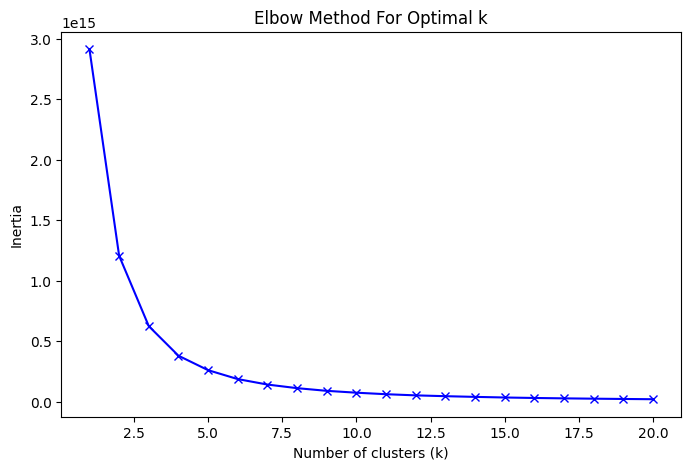

In [ ]:
## Unsupervised Learning - KMeans Clustering
print("KMeans Clustering")
onlyX = pd.read_csv('trainX.csv')
onlyX = onlyX[FEATURES]

# test with k 1-20 and plot elbow curve
inertia = []
K = range(1, 21)
for k in K:
    print(f"Fitting KMeans with k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(onlyX)
    inertia.append(kmeans.inertia_)
 

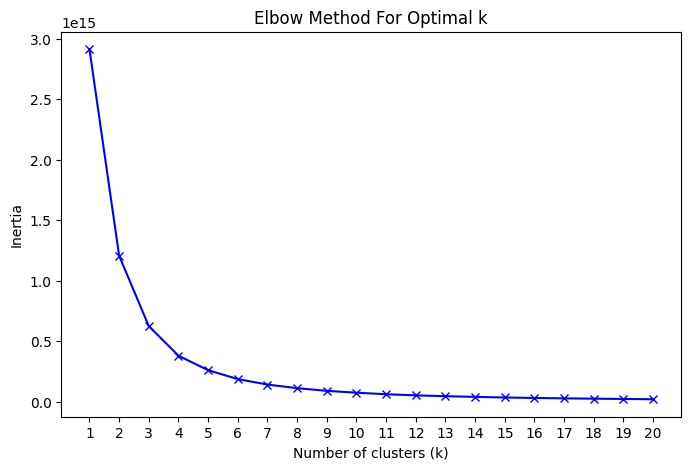

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(K)
plt.show() 

XGBoost with KMeans Cluster Features
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.15      0.90      0.25      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.94      0.62    555719
weighted avg       1.00      0.98      0.99    555719



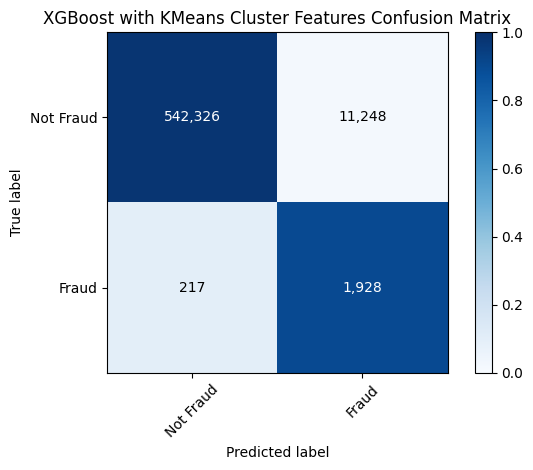

True Negative: 542326
False Positive: 11248
False Negative: 217
True Positive: 1928
True Negative Rate: 97.968%
True Positive Rate: 89.883%
False Positive Rate: 2.032%
False Negative Rate: 10.117%


In [27]:
onlyX = trainX.copy()
onlyX = onlyX[FEATURES]
onlyXTest = testX.copy()
onlyXTest = onlyXTest[FEATURES]

# Four clusters is the ideal number of clusters
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_final.fit(onlyX)

# Add cluster labels to training data
cluster_labels = kmeans_final.labels_
onlyX['cluster_label'] = cluster_labels

# One-hot encode cluster labels
cluster_dummies = pd.get_dummies(onlyX['cluster_label'], prefix='cluster')
onlyX = pd.concat([onlyX, cluster_dummies], axis=1)
onlyX = onlyX.drop(columns=['cluster_label'])

# Create extended feature list
FEATURES_EXTENDED = FEATURES + list(cluster_dummies.columns)

# Prepare training data
trainX_extended = onlyX

# Prepare test data with cluster features
test_cluster_labels = kmeans_final.predict(onlyXTest)
onlyXTest['cluster_label'] = test_cluster_labels

# One-hot encode test cluster labels
test_cluster_dummies = pd.get_dummies(onlyXTest['cluster_label'], prefix='cluster')
testX_extended = pd.concat([onlyXTest, test_cluster_dummies], axis=1)
testX_extended = testX_extended.drop(columns=['cluster_label'])

# Ensure test data has all the same cluster columns as training data
for col in cluster_dummies.columns:
    if col not in testX_extended.columns:
        testX_extended[col] = 0

# Reorder columns to match training data
testX_extended = testX_extended[FEATURES_EXTENDED]

print('XGBoost with KMeans Cluster Features')
print('=' * 50)
clf_XGB_kmeans = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='aucpr', 
    tree_method='hist', 
    colsample_bytree=0.7, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8
)
clf_XGB_kmeans.fit(trainX_extended, trainY)
y_pred_XGB_kmeans = clf_XGB_kmeans.predict(testX_extended)
print(classification_report(testY, y_pred_XGB_kmeans))

# Visual confusion matrix
cm_xgb_kmeans = confusion_matrix(testY, y_pred_XGB_kmeans)
visualizeMetrics(cm_xgb_kmeans, classes=['Not Fraud', 'Fraud'], 
                 title='XGBoost with KMeans Cluster Features Confusion Matrix')

In [28]:
# KMeans

from sklearn.cluster import KMeans

# preprocessing
numeric = ['is_weekend', 'is_nighttime', 'amt_to_median_ratio', 'amt_zscore', 'new_merchant_flag', 'category_frequency',
           'transDistance', 'merchant_travel_distance_24hr', 'impossible_travel_flag', 'transaction_count_1h',
           'transaction_count_24h', 'total_amount_1h', 'total_amount_24h', 'time_since_last_transaction']
categorical = ['day_of_week', 'hour_of_day']
preprocessor = ColumnTransformer(transformers=[
 ('num', StandardScaler(), numeric),
 ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])

# creating pipeline
pipeline = Pipeline([
 ('pre', preprocessor),
 ('kmeans', KMeans(n_clusters=2, random_state=0, n_init='auto'))
])

# fitting all of X
X = pd.concat(trainX + testX, axis=0).reset_index(drop=True)


pipeline.fit(X)

kmeans = pipeline.named_steps["kmeans"]
X_proc = pipeline.named_steps["preprocess"].transform(X)

# Access K-Means step
kmeans = pipeline.named_steps['kmeans']

# Access preprocessed features
X_proc = pipeline.named_steps['pre'].transform(X)

# Cluster assignments
labels = kmeans.labels_

# Cluster centers in the preprocessed space
centers = kmeans.cluster_centers_

# Distance to assigned cluster center
import numpy as np
distances = np.linalg.norm(X_proc - centers[labels], axis=1)

# Flag top 5% farthest transactions as potential fraud
threshold = np.percentile(distances, 95)
fraud_candidates = np.where(distances > threshold)[0]

print("Number of flagged transactions:", len(fraud_candidates))





TypeError: first argument must be an iterable of pandas objects, you passed an object of type "DataFrame"